In [3]:
pip install numpy


  Using cached numpy-2.4.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp314-cp314-macosx_14_0_arm64.whl (5.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from config import LEARNING_RATE, EPOCHS, NOISE_LEVELS, SEED
from models.hebbian import train_hebbian
from models.associative_memory import train_associative_memory, recall_pattern
from utils.patterns import make_demo_patterns, add_noise
from utils.metrics import recall_accuracy
from utils.plotting import plot_weight_history, show_pattern

np.random.seed(SEED)

### Part A: Hebbian learning

In [3]:
""" Part A – Basic Hebbian Learning

# In this section, you will train a simple Hebbian model on a small correlated dataset.
# You will observe how the weights change across epochs.

"""

# Correlated dataset
X_corr = np.array([
    [1.0, 1.0],
    [0.9, 1.1],
    [1.1, 0.95],
    [1.0, 0.9]
])

# TODO 2:
# Train the Hebbian model using X_corr
# Save the outputs as w_final and history
w_final, history = train_hebbian(X_corr)

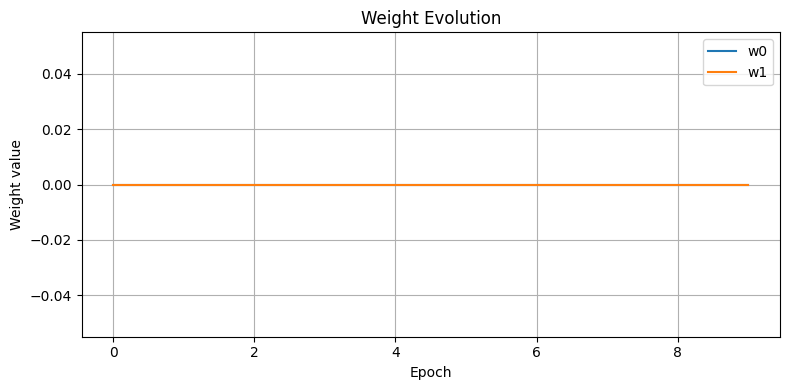

In [4]:
# TODO 3:
# Plot the weight evolution
plot_weight_history(history)

### Part B: Associative memory

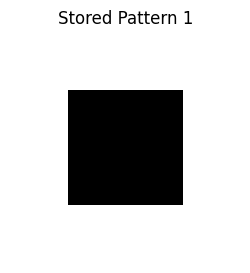

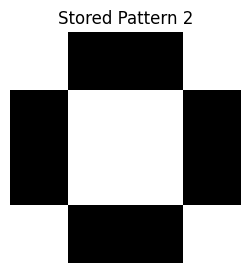

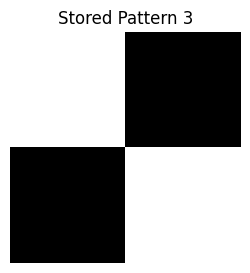

In [5]:
"""Part B – Associative Memory

In this section, you will store simple bipolar patterns using Hebbian learning.
Then you will provide a noisy cue and test whether the system can recover the original pattern.

"""
patterns = make_demo_patterns()

for i, p in enumerate(patterns):
    show_pattern(p, title=f"Stored Pattern {i+1}")

# TODO 6:
# Train the associative memory matrix W using the stored patterns

W = train_associative_memory(patterns)

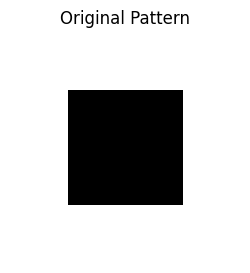

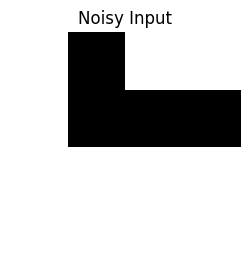

In [6]:
target = patterns[0]
noisy = add_noise(target, noise_level=0.25)

# TODO 7:
# Recall the pattern from the noisy input
# Save it as recalled
recalled = recall_pattern(W,noisy,steps=5)

show_pattern(target, title="Original Pattern")
show_pattern(noisy, title="Noisy Input")

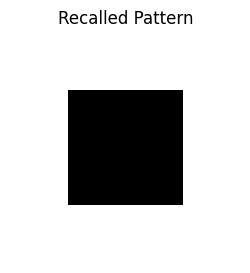

Recall Accuracy: 100.00%


In [7]:
# TODO 8:
# Display the recalled pattern
# Compute and print recall accuracy
show_pattern(recalled,title="Recalled Pattern")
acc = recall_accuracy(target,recalled)
print(f"Recall Accuracy: {acc:.2%}")

Section 4 – Noise experiment

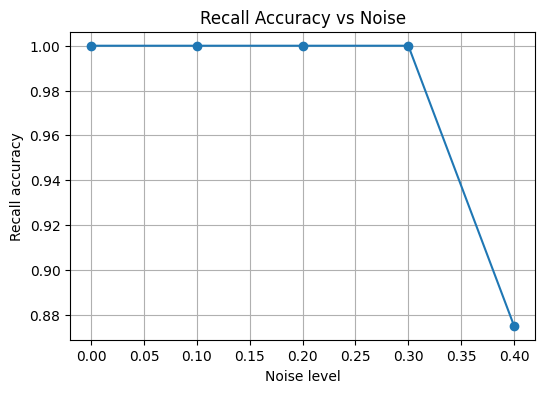

In [8]:
accs = []

for nl in NOISE_LEVELS:
    noisy = add_noise(target, noise_level=nl)
    recalled = recall_pattern(W, noisy, steps=5)
    acc = recall_accuracy(target, recalled)
    accs.append(acc)

plt.figure(figsize=(6,4))
plt.plot(NOISE_LEVELS, accs, marker='o')
plt.xlabel("Noise level")
plt.ylabel("Recall accuracy")
plt.title("Recall Accuracy vs Noise")
plt.grid(True)
plt.show()

Writing Questions
1. Why does Hebbian learning strengthen some connections more than others?
Hebbian learning follows the rule “cells that fire together wire together.”
The weight update is proportional to the product x * y. When a particular input feature (x) and the output (y) are both large and have the same sign, the corresponding weight grows a lot. In your correlated dataset X_corr, the two features always move together, so the weights that link them become much stronger than any other connections.

2. What happens to recall performance when noise increases?
Recall accuracy drops as noise level increases.
At low noise the cue is still close to the original pattern, so the network quickly converges back to the stored pattern. At high noise the cue becomes too different, and the dynamics may converge to a wrong (spurious) state or stay noisy. That’s exactly what the plot you generate in Section 4 shows.

3. What is one limitation of Hebbian learning?
One major limitation is unbounded weight growth (or very large weights) when there is no normalization or decay term.
In the simple Hebbian rule you implemented, weights only increase; there is no forgetting or upper bound. In the associative-memory version this also leads to a limited storage capacity (roughly 0.14 × number of neurons in a Hopfield-style network) and the appearance of spurious attractors.
